# Analiza syntetycznych danych zdrowotnych USA z ukrytymi zależnościami

W tym notebooku wykorzystano syntetyczne dane panelowe wygenerowane przy pomocy AI dla 50 stanów USA, aby ocenić skuteczność modelu analizy na alternatywnym zbiorze danych. Dane zostały zaprojektowane w taki sposób, aby zawierały ukryte grupy stanów, wynikające z różnic w takich czynnikach jak poziom ubóstwa, edukacja oraz warunki klimatyczne.


## 1. Wczytanie danych i przygotowanie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
from scipy.stats import spearmanr
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = {
    "Northeast": "#4C72B0",
    "Midwest": "#DD8452",
    "South": "#55A868",
    "West": "#C44E52",
}

In [2]:
STATES = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina",
    "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"
]
STATE_ABBR = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
]

REGION_MAP = {
    "Northeast": ["CT", "ME", "MA", "NH", "NJ", "NY", "PA", "RI", "VT"],
    "Midwest": ["IL", "IN", "IA", "KS", "MI", "MN", "MO", "NE", "ND", "OH", "SD", "WI"],
    "South": ["AL", "AR", "DE", "FL", "GA", "KY", "LA", "MD", "MS", "NC", "OK", "SC", "TN", "TX", "VA", "WV"],
    "West": ["AK", "AZ", "CA", "CO", "HI", "ID", "MT", "NV", "NM", "OR", "UT", "WA", "WY"],
}

DIVISION_MAP = {
    "New England": ["CT", "ME", "MA", "NH", "RI", "VT"],
    "Middle Atlantic": ["NJ", "NY", "PA"],
    "East North Central": ["IL", "IN", "MI", "OH", "WI"],
    "West North Central": ["IA", "KS", "MN", "MO", "NE", "ND", "SD"],
    "South Atlantic": ["DE", "FL", "GA", "MD", "NC", "SC", "VA", "WV"],
    "East South Central": ["AL", "KY", "MS", "TN"],
    "West South Central": ["AR", "LA", "OK", "TX"],
    "Mountain": ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY"],
    "Pacific": ["AK", "CA", "HI", "OR", "WA"],
}

GROUPS = {
    "Group1_South": ["AL", "AR", "FL", "GA", "KY", "LA", "MS", "NC", "OK", "SC", "TN", "TX", "WV"],
    "Group2_Northeast": ["CT", "MA", "MD", "ME", "NH", "NJ", "NY", "PA", "RI", "VT"],
    "Group3_West": ["AK", "AZ", "CA", "CO", "HI", "NV", "NM", "OR", "UT", "WA"],
    "Group4_Midwest": ["IA", "ID", "IL", "IN", "KS", "MI", "MN", "MO", "MT", "ND", "NE", "OH", "SD", "WI", "WY"],
}


In [3]:
def generate_synthetic_data():
    np.random.seed(42)
    years = list(range(2011, 2024))
    rows = []
    for state, abbr in zip(STATES, STATE_ABBR):
        group = next((g for g, codes in GROUPS.items() if abbr in codes), None)
        if group is None:
            continue
        if group == "Group1_South":
            poverty_factor, education_factor, urban_factor, climate_factor = 0.8, 0.2, 0.3, 0.8
        elif group == "Group2_Northeast":
            poverty_factor, education_factor, urban_factor, climate_factor = 0.2, 0.8, 0.8, 0.2
        elif group == "Group3_West":
            poverty_factor, education_factor, urban_factor, climate_factor = 0.4, 0.7, 0.5, 0.7
        else:
            poverty_factor, education_factor, urban_factor, climate_factor = 0.5, 0.5, 0.2, 0.3
        region = next((r for r, codes in REGION_MAP.items() if abbr in codes), None)
        division = next((d for d, codes in DIVISION_MAP.items() if abbr in codes), None)
        base_pop = np.clip(500000 + 1500000 * (0.5 + 0.5 * education_factor) * (0.8 + 0.4 * poverty_factor) * np.random.rand(), 150000, 12000000)
        for year in years:
            trend = (year - 2011) * 0.01
            populacja_total = int(np.clip(base_pop * (1 + 0.005 * (year - 2011) + np.random.normal(0, 0.01)), 100000, 12000000))
            obesity = np.clip(25 + 15 * poverty_factor - 10 * education_factor - 5 * climate_factor + np.random.normal(0, 2) + trend, 10, 50)
            overweight = np.clip(obesity + 10 + np.random.normal(0, 4), 20, 80)
            low_fruits = np.clip(40 + 20 * poverty_factor - 15 * education_factor + np.random.normal(0, 5), 10, 70)
            low_veggies = np.clip(40 + 18 * poverty_factor - 12 * education_factor + np.random.normal(0, 5), 10, 70)
            high_activity = np.clip(25 - 10 * poverty_factor + 15 * education_factor + 5 * climate_factor + np.random.normal(0, 3) - trend, 10, 55)
            mod_activity = np.clip(30 - 5 * poverty_factor + 10 * education_factor + np.random.normal(0, 5), 10, 60)
            muscle_activity = np.clip(12 - 5 * poverty_factor + 10 * urban_factor + np.random.normal(0, 4), 5, 35)
            no_activity = np.clip(20 + 15 * poverty_factor - 10 * education_factor - 3 * climate_factor + np.random.normal(0, 2), 5, 45)
            mediana_dochodu_gosp_dom = np.clip(50000 - 20000 * poverty_factor + 30000 * education_factor + np.random.normal(0, 5000), 30000, 120000)
            pct_ubóstwo = np.clip(15 + 20 * poverty_factor - 10 * education_factor + np.random.normal(0, 2), 5, 30)
            pct_zatrudnieni = np.clip(55 + 10 * education_factor - 10 * poverty_factor + np.random.normal(0, 3), 45, 75)
            pct_bezrobocie = np.clip(5 + 10 * poverty_factor - 5 * education_factor + np.random.normal(0, 1), 2, 15)
            pct_wyksztalcenie_srednie = np.clip(40 + 15 * (1 - education_factor) + np.random.normal(0, 4), 20, 70)
            pct_wyksztalcenie_wyzsze = np.clip(20 + 35 * education_factor + np.random.normal(0, 5), 10, 60)
            pct_bez_ubezpieczenia = np.clip(10 + 15 * poverty_factor - 10 * education_factor + np.random.normal(0, 2), 5, 30)
            work_home = np.clip(5 + 15 * urban_factor + np.random.normal(0, 2), 2, 25)
            car = np.clip(80 - 30 * urban_factor + np.random.normal(0, 5), 40, 95)
            carpool = np.clip(5 + 10 * (1 - urban_factor) + np.random.normal(0, 2), 1, 20)
            transport_pub = np.clip(5 + 10 * urban_factor + np.random.normal(0, 3), 1, 25)
            pieszo = np.clip(2 + 5 * urban_factor + np.random.normal(0, 2), 0, 15)
            total_commute = car + carpool + transport_pub + pieszo
            if total_commute > 0:
                scale = (100 - work_home) / total_commute
                car *= scale
                carpool *= scale
                transport_pub *= scale
                pieszo *= scale
            pct_dojazd_samochod = np.clip(car, 30, 95)
            pct_dojazd_carpool = np.clip(carpool, 1, 20)
            pct_dojazd_transport_pub = np.clip(transport_pub, 1, 30)
            pct_dojazd_pieszo = np.clip(pieszo, 0, 15)
            pct_praca_z_domu = work_home
            sredni_czas_dojazdu_min = np.clip(20 + 10 * (1 - urban_factor) + np.random.normal(0, 5), 10, 45)
            pct_ponizej_18lat = np.clip(22 + 5 * poverty_factor - 3 * education_factor + np.random.normal(0, 2), 15, 30)
            pct_powyzej_65lat = np.clip(15 - 2 * poverty_factor + 2 * education_factor + np.random.normal(0, 2), 10, 25)
            pct_mieszkania_wynajmowane = np.clip(30 + 10 * urban_factor - 5 * education_factor + np.random.normal(0, 5), 15, 60)
            liczba_jednostek_mieszkalnych = int(np.clip(populacja_total / 2.5 * np.clip(0.45 + 0.1 * education_factor + np.random.normal(0, 0.03), 0.35, 0.7), 15000, 2000000))
            liczba_gospodarstw_domowych = int(np.clip(populacja_total / 2.6 * np.clip(0.9 + 0.05 * education_factor + np.random.normal(0, 0.02), 0.8, 1.1), 10000, 1000000))
            pct_gospodarstwa_z_dziecmi = np.clip(30 + 5 * poverty_factor - 5 * education_factor + np.random.normal(0, 4), 15, 50)
            pct_dostep_internet = np.clip(75 + 15 * education_factor + 10 * urban_factor - 5 * poverty_factor + np.random.normal(0, 4), 60, 99)
            avg_temp = np.clip(10 + 20 * climate_factor + np.random.normal(0, 3), 0, 30)
            avg_prcp = np.clip(40 + 20 * climate_factor + np.random.normal(0, 10), 10, 200)
            fitness_centers_estab = int(np.clip(40 + 100 * urban_factor + 20 * education_factor - 20 * poverty_factor + np.random.normal(0, 25), 5, 400))
            liquor_stores_estab = int(np.clip(15 + 80 * poverty_factor + 30 * urban_factor + np.random.normal(0, 15), 5, 260))
            fitness_per_100k = np.clip(fitness_centers_estab / (populacja_total / 1e5), 5, 200)
            rows.append({
                "Year": year,
                "LocationDesc": state,
                "LocationAbbr": abbr,
                "HighActivity": high_activity,
                "LowFruits": low_fruits,
                "LowVeggies": low_veggies,
                "ModActivity": mod_activity,
                "MuscleActivity": muscle_activity,
                "NoActivity": no_activity,
                "Obesity": obesity,
                "Overweight": overweight,
                "populacja_total": populacja_total,
                "pct_ponizej_18lat": pct_ponizej_18lat,
                "pct_powyzej_65lat": pct_powyzej_65lat,
                "mediana_dochodu_gosp_dom": mediana_dochodu_gosp_dom,
                "pct_ubóstwo": pct_ubóstwo,
                "pct_zatrudnieni": pct_zatrudnieni,
                "pct_bezrobocie": pct_bezrobocie,
                "pct_dojazd_samochod": pct_dojazd_samochod,
                "pct_dojazd_carpool": pct_dojazd_carpool,
                "pct_dojazd_transport_pub": pct_dojazd_transport_pub,
                "pct_dojazd_pieszo": pct_dojazd_pieszo,
                "pct_praca_z_domu": pct_praca_z_domu,
                "sredni_czas_dojazdu_min": sredni_czas_dojazdu_min,
                "pct_wyksztalcenie_srednie": pct_wyksztalcenie_srednie,
                "pct_wyksztalcenie_wyzsze": pct_wyksztalcenie_wyzsze,
                "pct_bez_ubezpieczenia": pct_bez_ubezpieczenia,
                "liczba_jednostek_mieszkalnych": liczba_jednostek_mieszkalnych,
                "pct_mieszkania_wynajmowane": pct_mieszkania_wynajmowane,
                "liczba_gospodarstw_domowych": liczba_gospodarstw_domowych,
                "pct_gospodarstwa_z_dziecmi": pct_gospodarstwa_z_dziecmi,
                "pct_dostep_internet": pct_dostep_internet,
                "avg_temp": avg_temp,
                "avg_prcp": avg_prcp,
                "fitness_centers_estab": fitness_centers_estab,
                "liquor_stores_estab": liquor_stores_estab,
                "Region": region,
                "Division": division,
                "fitness_per_100k": fitness_per_100k,
            })
    return pd.DataFrame(rows)

df = generate_synthetic_data()

In [4]:
df.head()

,Year,LocationDesc,LocationAbbr,HighActivity,LowFruits,LowVeggies,ModActivity,MuscleActivity,NoActivity,Obesity,...,liczba_gospodarstw_domowych,pct_gospodarstwa_z_dziecmi,pct_dostep_internet,avg_temp,avg_prcp,fitness_centers_estab,liquor_stores_estab,Region,Division,fitness_per_100k
0,2011,Alabama,AL,22.424491,58.052576,49.095609,25.143099,7.303669,22.374902,31.637804,...,296903,32.352978,74.865405,25.983416,53.705495,67,69,South,East South Central,7.720860
1,2012,Alabama,AL,20.962744,54.093192,56.408805,20.083529,14.094802,26.523717,36.566626,...,314060,28.848680,76.696785,28.918891,63.955955,95,93,South,East South Central,10.656126
2,2013,Alabama,AL,27.107475,52.695680,44.906248,32.517662,11.076001,26.531167,29.179218,...,301859,34.382072,75.417934,25.132589,60.529363,53,91,South,East South Central,5.786633
3,2014,Alabama,AL,20.752404,52.907246,43.632477,23.037069,11.409391,26.734781,29.143886,...,306049,31.026270,80.692650,30.000000,64.735894,58,82,South,East South Central,6.644122
4,2015,Alabama,AL,23.477188,48.426545,55.102741,26.058678,7.457951,26.886510,28.594253,...,322545,38.300423,79.938004,23.136508,48.488206,29,99,South,East South Central,5.000000


In [5]:
df.columns

Index(['Year', 'LocationDesc', 'LocationAbbr', 'HighActivity', 'LowFruits',
       'LowVeggies', 'ModActivity', 'MuscleActivity', 'NoActivity', 'Obesity',
       'Overweight', 'populacja_total', 'pct_ponizej_18lat',
       'pct_powyzej_65lat', 'mediana_dochodu_gosp_dom', 'pct_ubóstwo',
       'pct_zatrudnieni', 'pct_bezrobocie', 'pct_dojazd_samochod',
       'pct_dojazd_carpool', 'pct_dojazd_transport_pub', 'pct_dojazd_pieszo',
       'pct_praca_z_domu', 'sredni_czas_dojazdu_min',
       'pct_wyksztalcenie_srednie', 'pct_wyksztalcenie_wyzsze',
       'pct_bez_ubezpieczenia', 'liczba_jednostek_mieszkalnych',
       'pct_mieszkania_wynajmowane', 'liczba_gospodarstw_domowych',
       'pct_gospodarstwa_z_dziecmi', 'pct_dostep_internet', 'avg_temp',
       'avg_prcp', 'fitness_centers_estab', 'liquor_stores_estab', 'Region',
       'Division', 'fitness_per_100k'],
      dtype='str')

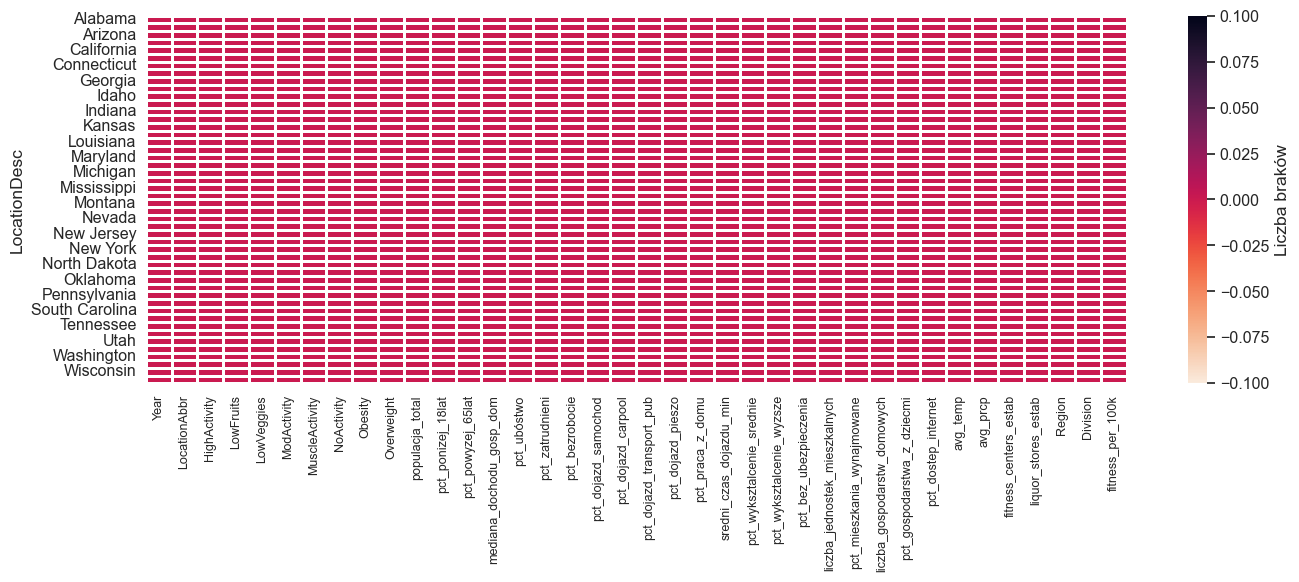

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
heat_data = df.groupby(["LocationDesc"]).apply(lambda x: x.isna().sum())
sns.heatmap(
    heat_data,
    cmap="rocket_r",
    linewidths=0.8,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Liczba braków"},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=9)
ax.tick_params(axis="x", which="major", length=5, width=0.8)
ax.tick_params(axis="y", which="major", length=3, width=0.6)
plt.tight_layout()
plt.show()

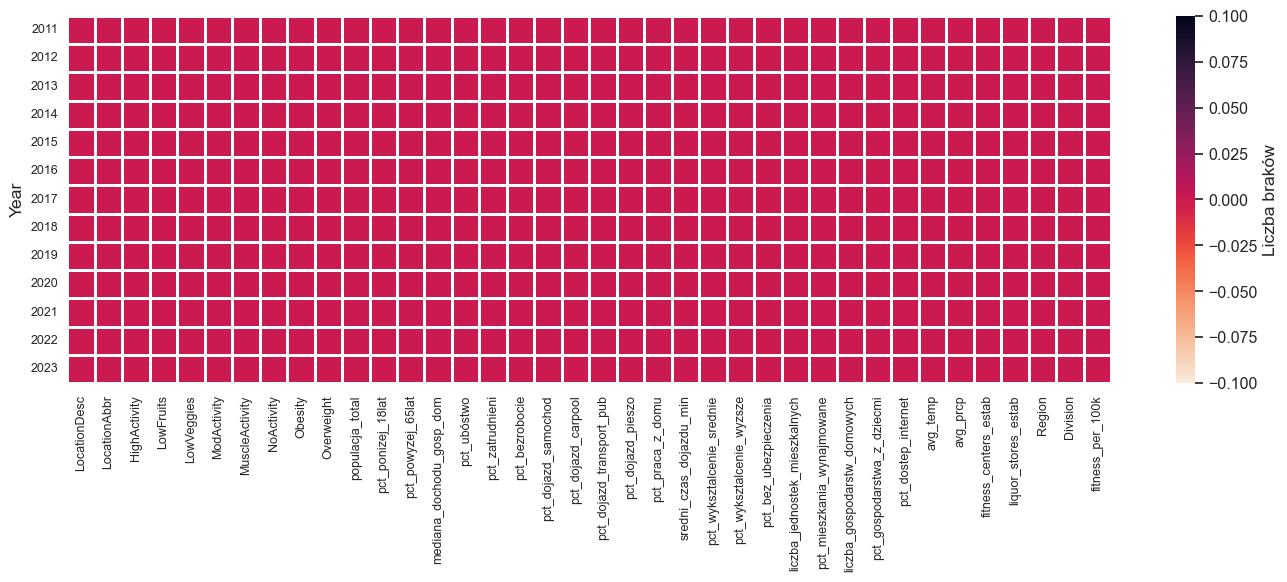

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
heat_data = df.groupby(["Year"]).apply(lambda x: x.isna().sum())
sns.heatmap(
    heat_data,
    cmap="rocket_r",
    linewidths=0.8,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Liczba braków"},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center", fontsize=9)
ax.tick_params(axis="x", which="major", length=5, width=0.8)
ax.tick_params(axis="y", which="major", length=3, width=0.6)
plt.tight_layout()
plt.show()

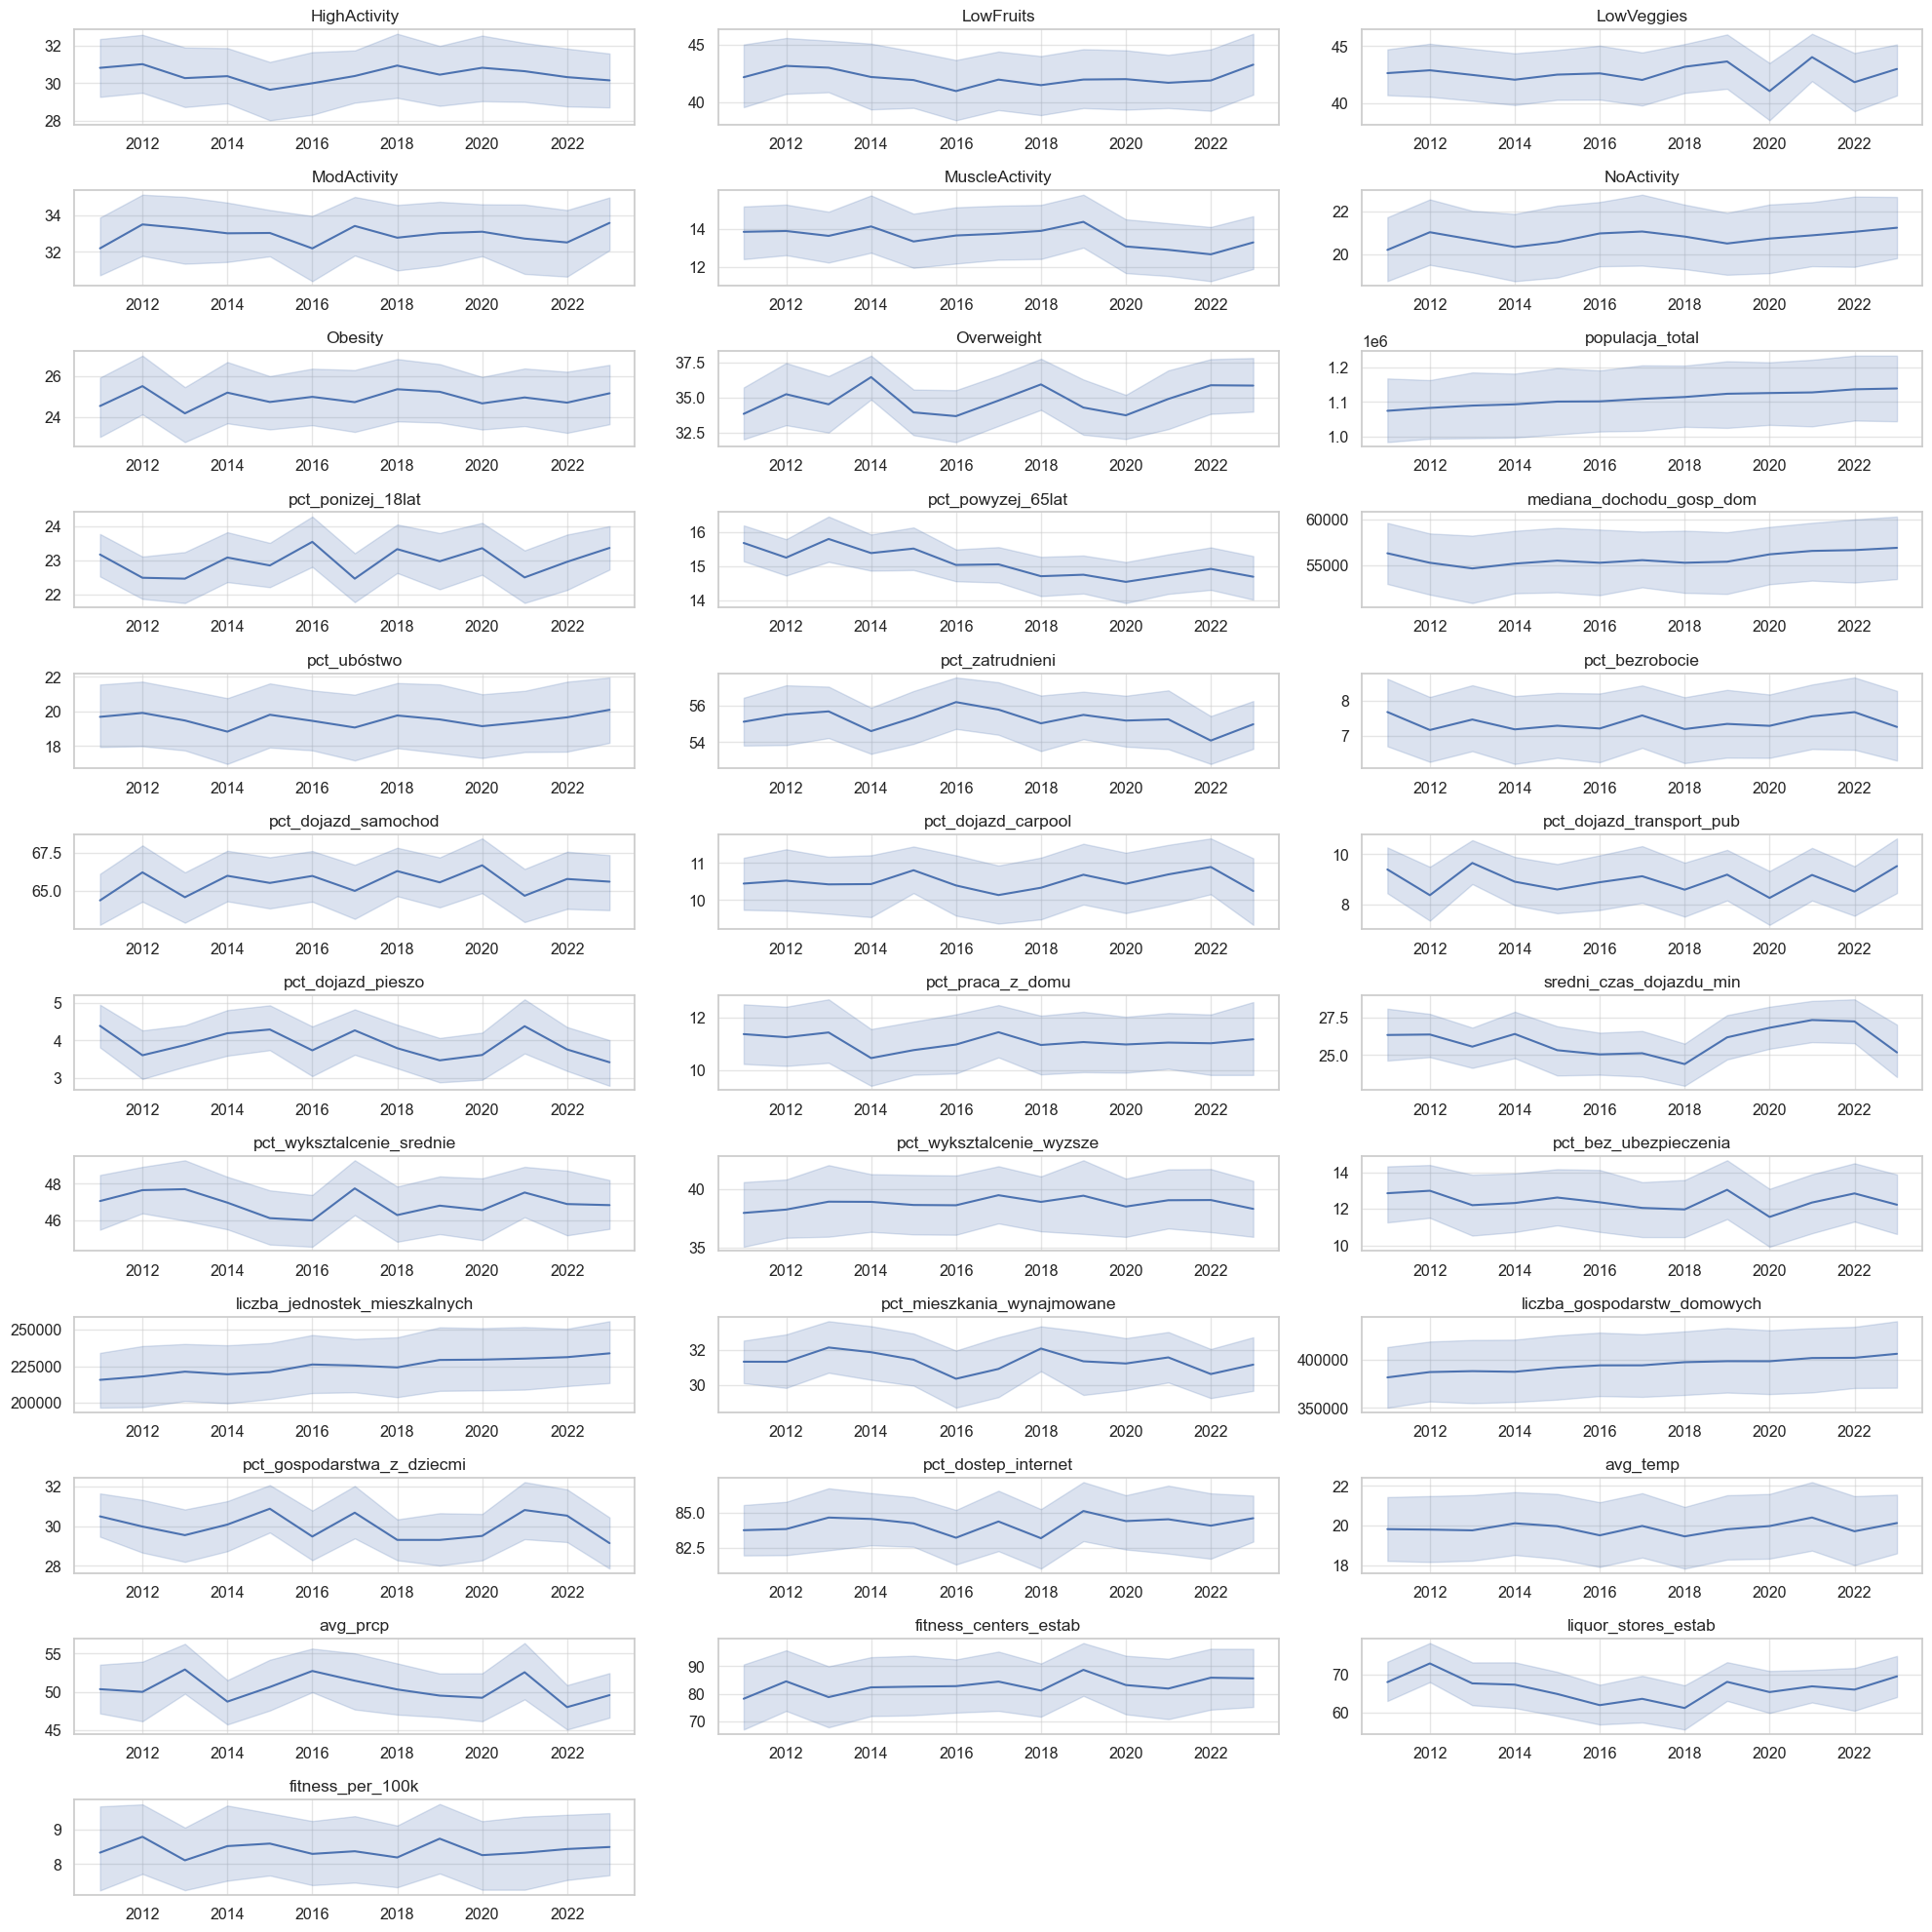

In [9]:
vars = df.drop(columns=["Region", "Division"]).columns[3:]
n = len(vars)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(vars):
    ax = axes[i]
    sns.lineplot(data=df, x="Year", y=col, ax=ax)

    missing_years = df.loc[df[col].isna(), "Year"].dropna().unique()
    if len(missing_years) > 0:
        y0, y1 = ax.get_ylim()
        y_missing = y0 + 0.05 * (y1 - y0)
        ax.scatter(
            missing_years,
            [y_missing] * len(missing_years),
            color="crimson",
            marker="o",
            s=45,
            label="Brak danych",
            zorder=5,
        )
        ax.legend(fontsize=8, loc="best")

    ax.set_title(col)
    ax.set_ylabel("")
    ax.set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [10]:
# usredniony profil per stan (do PCA i klastrowania)
CLUSTER_COLS = [
    "Obesity",
    "NoActivity",
    "HighActivity",
    "mediana_dochodu_gosp_dom",
    "pct_ubóstwo",
    "pct_bezrobocie",
    "pct_wyksztalcenie_wyzsze",
    "pct_bez_ubezpieczenia",
    "pct_dojazd_samochod",
    "pct_praca_z_domu",
    "fitness_per_100k",
    "avg_temp",
]

In [11]:
# # Wersja z samymi danymi z 2023

# df_state = df[df['Year']==2023][["LocationDesc", "LocationAbbr", "Region", "Division"] + CLUSTER_COLS]

# print(f"Stany w zbiorze 2023: {len(df_state)}")
# print(f"Braki w danych: {df_state[CLUSTER_COLS].isna().sum().sum()}")

In [12]:
# Wersja z agregacją do średniej

df_state = (
    df[df["Region"].notna()]
    .groupby(["LocationDesc", "LocationAbbr", "Region", "Division"])[CLUSTER_COLS]
    .mean()
    .reset_index()
)

# imputacja brakow mediana z regionu (dotyczy avg_temp - 10 stanow bez danych NOAA)
for col in CLUSTER_COLS:
    if df_state[col].isna().any():
        region_median = df_state.groupby("Region")[col].median()
        df_state[col] = df_state.apply(
            lambda row: region_median[row["Region"]] if pd.isna(row[col]) else row[col],
            axis=1,
        )

print(f"Stany w zbiorze usrednionym: {len(df_state)}")
print(f"Braki po imputacji: {df_state[CLUSTER_COLS].isna().sum().sum()}")

Stany w zbiorze usrednionym: 48
Braki po imputacji: 0


## 2. Statystyki opisowe

In [13]:
DESC_COLS = {
    "Obesity": "otylosc [%]",
    "NoActivity": "brak aktywnosci [%]",
    "HighActivity": "wysoka aktywnosc [%]",
    "mediana_dochodu_gosp_dom": "mediana dochodu [USD]",
    "pct_ubóstwo": "ubostwo [%]",
    "pct_wyksztalcenie_wyzsze": "wyzsze wyksztalcenie [%]",
    "pct_bez_ubezpieczenia": "bez ubezpieczenia [%]",
    "fitness_per_100k": "silownie / 100k mieszk.",
}

desc = df_state[list(DESC_COLS.keys())].describe().T
desc.index = [DESC_COLS[c] for c in desc.index]
desc = desc[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)
desc.columns = ["srednia", "std", "min", "Q1", "mediana", "Q3", "max"]
desc

,srednia,std,min,Q1,mediana,Q3,max
otylosc [%],24.93,4.73,18.03,20.41,26.03,30.61,31.93
brak aktywnosci [%],20.78,5.08,12.81,16.28,21.20,26.78,28.63
wysoka aktywnosc [%],30.45,4.89,23.36,24.56,29.52,35.25,37.59
mediana dochodu [USD],55753.30,11081.25,37137.93,41370.10,55727.34,64173.23,72425.12
ubostwo [%],19.53,6.45,10.35,15.65,19.29,28.27,29.10
wyzsze wyksztalcenie [%],38.80,8.03,24.74,30.20,39.60,45.10,51.95
bez ubezpieczenia [%],12.41,5.35,5.25,8.82,11.96,19.13,20.96
silownie / 100k mieszk.,8.42,2.90,5.02,5.96,8.00,10.02,14.98


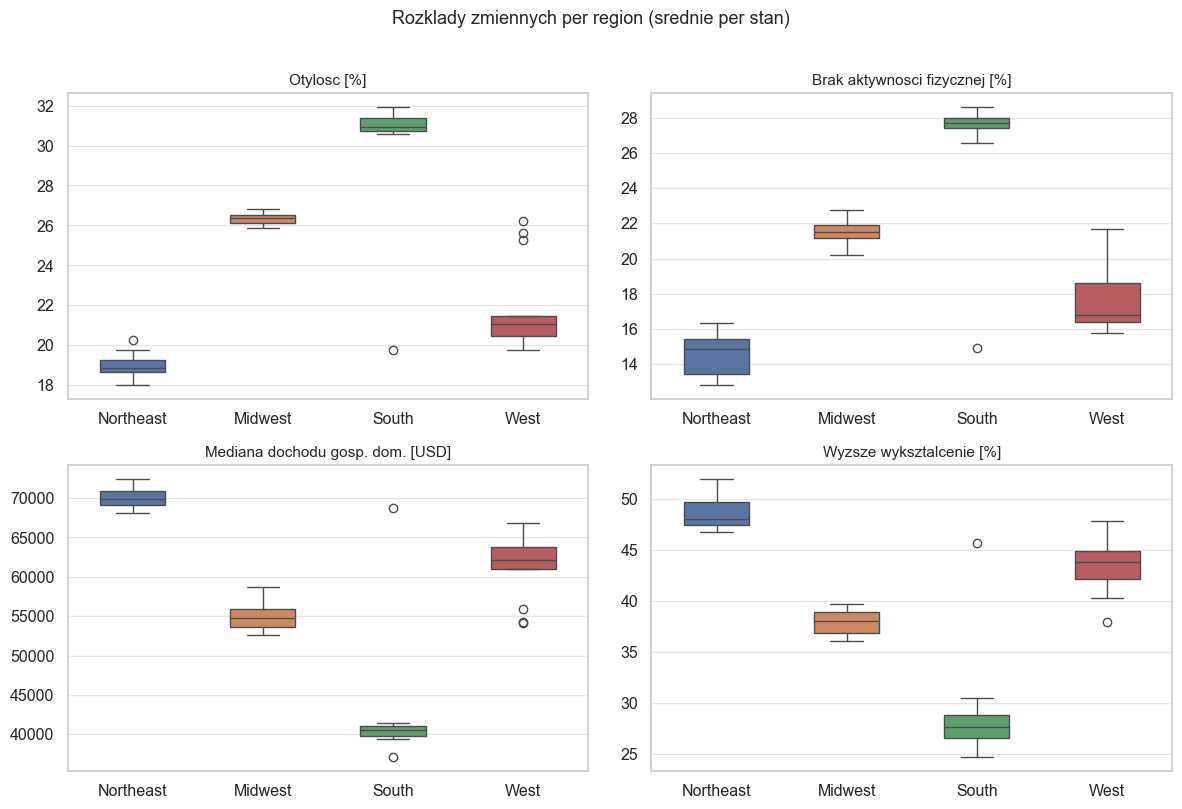

In [14]:
# rozklady kluczowych zmiennych per region

BOXPLOT_VARS = [
    ("Obesity", "Otylosc [%]"),
    ("NoActivity", "Brak aktywnosci fizycznej [%]"),
    ("mediana_dochodu_gosp_dom", "Mediana dochodu gosp. dom. [USD]"),
    ("pct_wyksztalcenie_wyzsze", "Wyzsze wyksztalcenie [%]"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, BOXPLOT_VARS):
    order = ["Northeast", "Midwest", "South", "West"]
    sns.boxplot(
        data=df_state, x="Region", y=col, order=order, palette=PALETTE, width=0.5, ax=ax
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Rozklady zmiennych per region (srednie per stan)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
df_state_temp = (
    df[df["Region"].notna()]
    .groupby(["LocationDesc", "LocationAbbr", "Region"])[["mediana_dochodu_gosp_dom"]]
    .mean()
    .reset_index()
)

result = (df_state_temp[df_state_temp["Region"] == "South"]
    .sort_values("mediana_dochodu_gosp_dom", ascending=False)
    .reset_index(drop=True))

print(result.to_string(index=False))

  LocationDesc LocationAbbr Region  mediana_dochodu_gosp_dom
      Maryland           MD  South              68727.163955
   Mississippi           MS  South              41468.507254
       Florida           FL  South              41074.868169
       Alabama           AL  South              41074.366804
      Oklahoma           OK  South              40980.175028
 West Virginia           WV  South              40730.584345
      Kentucky           KY  South              40630.462876
     Louisiana           LA  South              40544.568993
     Tennessee           TN  South              40390.473514
      Arkansas           AR  South              39856.196466
South Carolina           SC  South              39726.454747
         Texas           TX  South              39504.042182
North Carolina           NC  South              39408.937007
       Georgia           GA  South              37137.931194


## 3. Trendy czasowe

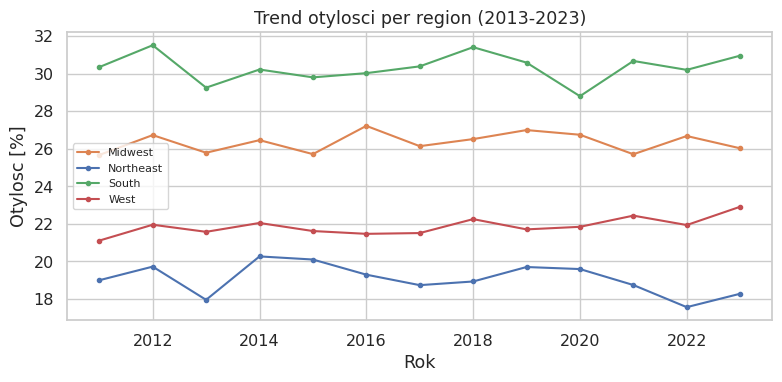

In [65]:
trend_region = (
    df[df["Region"].notna()].groupby(["Year", "Region"])["Obesity"].mean().reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))

for region, grp in trend_region.groupby("Region"):
    ax.plot(
        grp["Year"],
        grp["Obesity"],
        marker="o",
        markersize=3,
        label=region,
        color=PALETTE[region],
    )

ax.set_title("Trend otylosci per region (2013-2023)")
ax.set_xlabel("Rok")
ax.set_ylabel("Otylosc [%]")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [66]:
# interaktywny podglad: otylosc per stan w czasie
trend_states = (
    df[df["Region"].notna()]
    .groupby(["Year", "LocationDesc", "LocationAbbr", "Region"])["Obesity"]
    .mean()
    .reset_index()
)

fig = px.line(
    trend_states,
    x="Year",
    y="Obesity",
    color="Region",
    line_group="LocationDesc",
    hover_name="LocationDesc",
    color_discrete_map=PALETTE,
    labels={"Obesity": "Otylosc [%]", "Year": "Rok"},
    title="Otylosc per stan w czasie (2013-2023)",
)
fig.update_traces(opacity=0.55, line_width=1.2)
fig.update_layout(height=450)
fig.show()

## 4. Macierz korelacji

In [67]:
CLUSTER_COLS

['Obesity',
 'NoActivity',
 'HighActivity',
 'mediana_dochodu_gosp_dom',
 'pct_ubóstwo',
 'pct_bezrobocie',
 'pct_wyksztalcenie_wyzsze',
 'pct_bez_ubezpieczenia',
 'pct_dojazd_samochod',
 'pct_praca_z_domu',
 'fitness_per_100k',
 'avg_temp']

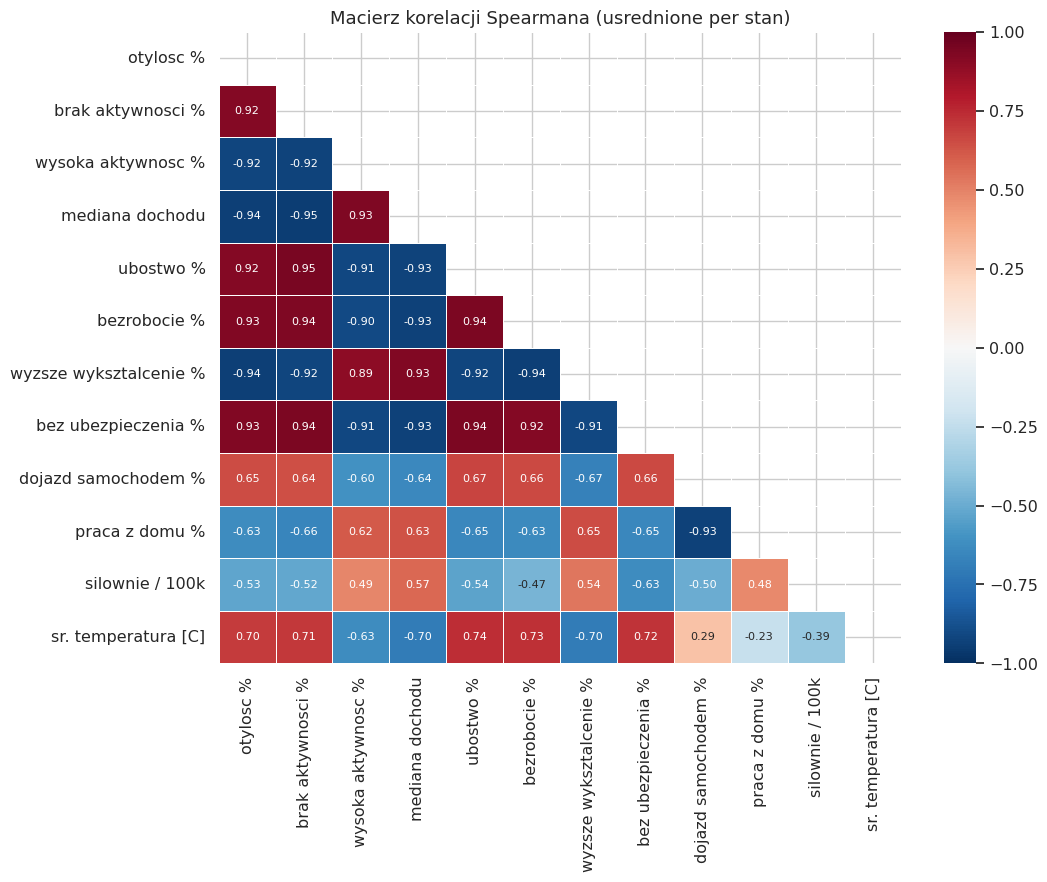

In [68]:
HEATMAP_COLS = {
    "Obesity": "otylosc %",
    "NoActivity": "brak aktywnosci %",
    "HighActivity": "wysoka aktywnosc %",
    "mediana_dochodu_gosp_dom": "mediana dochodu",
    "pct_ubóstwo": "ubostwo %",
    "pct_bezrobocie": "bezrobocie %",
    "pct_wyksztalcenie_wyzsze": "wyzsze wyksztalcenie %",
    "pct_bez_ubezpieczenia": "bez ubezpieczenia %",
    "pct_dojazd_samochod": "dojazd samochodem %",
    "pct_praca_z_domu": "praca z domu %",
    "fitness_per_100k": "silownie / 100k",
    "avg_temp": "sr. temperatura [C]",
}

corr_data = df_state[list(HEATMAP_COLS.keys())].copy()
corr_data.columns = list(HEATMAP_COLS.values())
corr_matrix = corr_data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Macierz korelacji Spearmana (usrednione per stan)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Kluczowe zaleznosci - wykresy punktowe

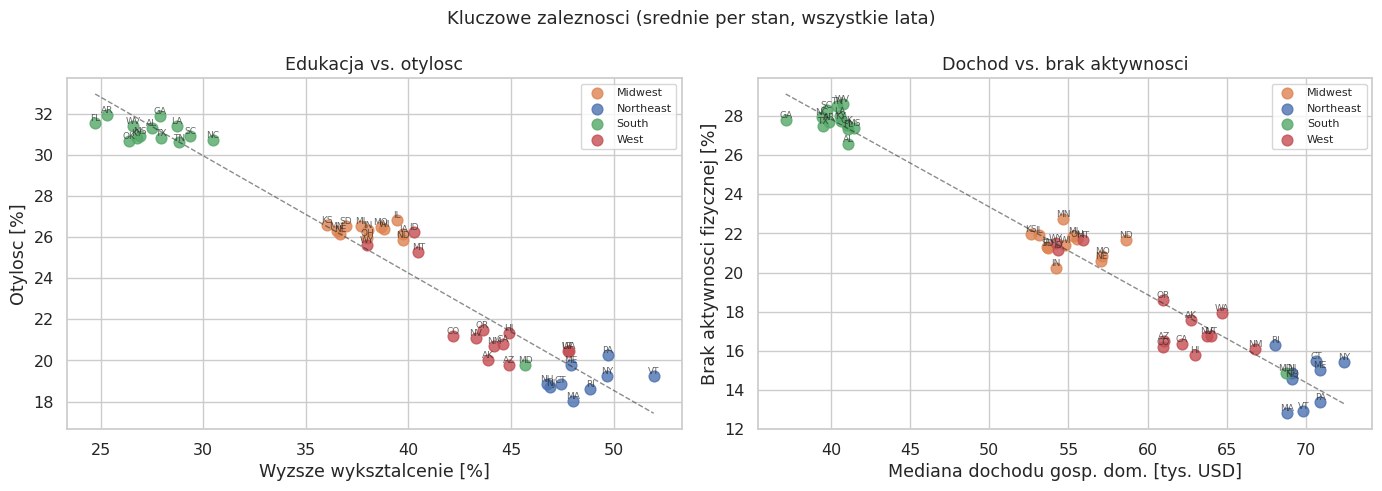

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# edukacja vs otylosc
ax = axes[0]
for region, grp in df_state.groupby("Region"):
    ax.scatter(
        grp["pct_wyksztalcenie_wyzsze"],
        grp["Obesity"],
        label=region,
        color=PALETTE[region],
        s=60,
        alpha=0.8,
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row["LocationAbbr"],
            (row["pct_wyksztalcenie_wyzsze"], row["Obesity"]),
            fontsize=6.5,
            ha="center",
            va="bottom",
            alpha=0.7,
        )

m, b = np.polyfit(df_state["pct_wyksztalcenie_wyzsze"], df_state["Obesity"], 1)
x_line = np.linspace(
    df_state["pct_wyksztalcenie_wyzsze"].min(),
    df_state["pct_wyksztalcenie_wyzsze"].max(),
    100,
)
ax.plot(x_line, m * x_line + b, "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("Wyzsze wyksztalcenie [%]")
ax.set_ylabel("Otylosc [%]")
ax.set_title("Edukacja vs. otylosc")
ax.legend(fontsize=8)

# dochod vs brak aktywnosci
ax = axes[1]
for region, grp in df_state.groupby("Region"):
    ax.scatter(
        grp["mediana_dochodu_gosp_dom"] / 1000,
        grp["NoActivity"],
        label=region,
        color=PALETTE[region],
        s=60,
        alpha=0.8,
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row["LocationAbbr"],
            (row["mediana_dochodu_gosp_dom"] / 1000, row["NoActivity"]),
            fontsize=6.5,
            ha="center",
            va="bottom",
            alpha=0.7,
        )

m2, b2 = np.polyfit(
    df_state["mediana_dochodu_gosp_dom"] / 1000, df_state["NoActivity"], 1
)
x_line2 = np.linspace(
    (df_state["mediana_dochodu_gosp_dom"] / 1000).min(),
    (df_state["mediana_dochodu_gosp_dom"] / 1000).max(),
    100,
)
ax.plot(x_line2, m2 * x_line2 + b2, "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("Mediana dochodu gosp. dom. [tys. USD]")
ax.set_ylabel("Brak aktywnosci fizycznej [%]")
ax.set_title("Dochod vs. brak aktywnosci")
ax.legend(fontsize=8)

plt.suptitle("Kluczowe zaleznosci (srednie per stan, wszystkie lata)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. PCA

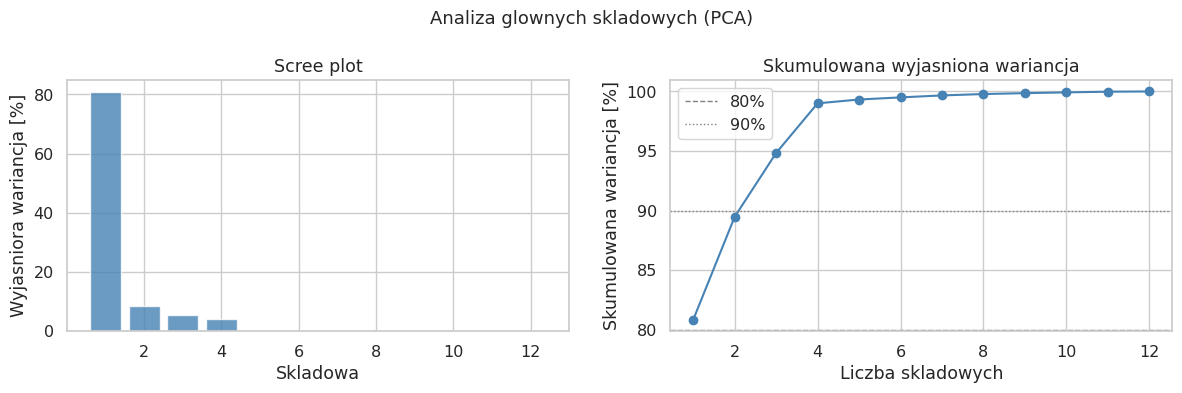

PC1: 80.8%,  PC2: 8.6%,  PC3: 5.4%
PC1+PC2: 89.5%,  PC1+PC2+PC3: 94.8%


In [70]:
X = df_state[CLUSTER_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(range(1, len(explained) + 1), explained * 100, color="steelblue", alpha=0.8)
ax.set_xlabel("Skladowa")
ax.set_ylabel("Wyjasniora wariancja [%]")
ax.set_title("Scree plot")

ax = axes[1]
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="steelblue")
ax.axhline(80, linestyle="--", color="gray", linewidth=1, label="80%")
ax.axhline(90, linestyle=":", color="gray", linewidth=1, label="90%")
ax.set_xlabel("Liczba skladowych")
ax.set_ylabel("Skumulowana wariancja [%]")
ax.set_title("Skumulowana wyjasniona wariancja")
ax.legend()

plt.suptitle("Analiza glownych skladowych (PCA)", fontsize=13)
plt.tight_layout()
plt.show()

print(
    f"PC1: {explained[0]*100:.1f}%,  PC2: {explained[1]*100:.1f}%,  PC3: {explained[2]*100:.1f}%"
)
print(f"PC1+PC2: {cumulative[1]*100:.1f}%,  PC1+PC2+PC3: {cumulative[2]*100:.1f}%")

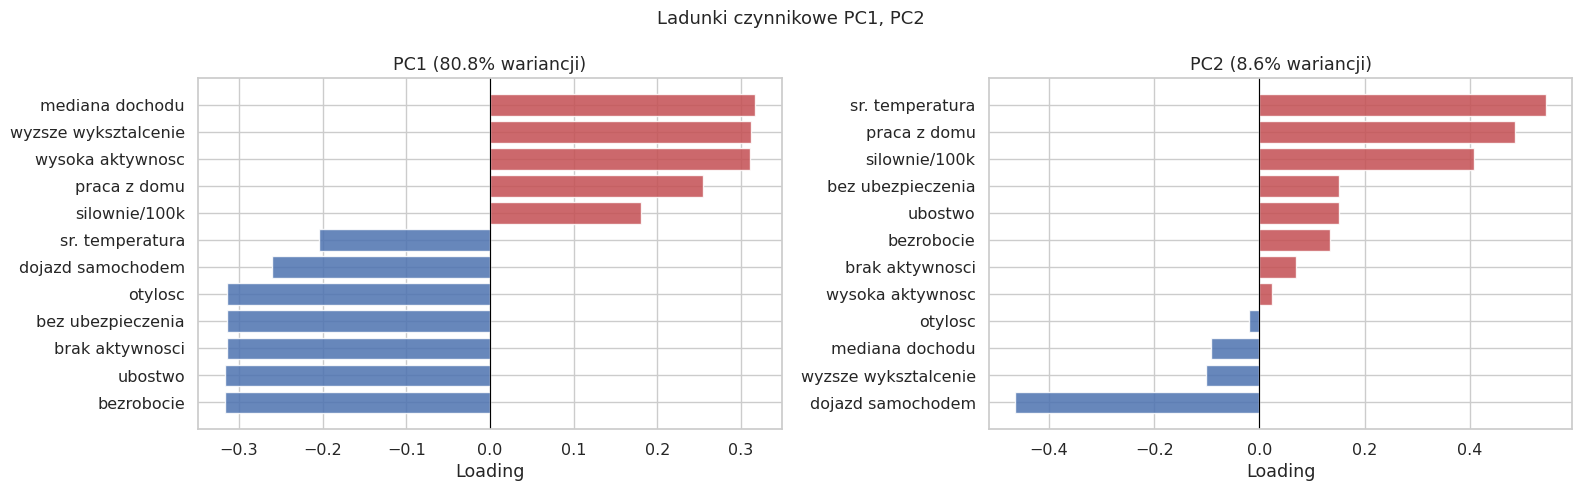

In [71]:
COL_LABELS = {
    "Obesity": "otylosc",
    "NoActivity": "brak aktywnosci",
    "HighActivity": "wysoka aktywnosc",
    "mediana_dochodu_gosp_dom": "mediana dochodu",
    "pct_ubóstwo": "ubostwo",
    "pct_bezrobocie": "bezrobocie",
    "pct_wyksztalcenie_wyzsze": "wyzsze wyksztalcenie",
    "pct_bez_ubezpieczenia": "bez ubezpieczenia",
    "pct_dojazd_samochod": "dojazd samochodem",
    "pct_praca_z_domu": "praca z domu",
    "fitness_per_100k": "silownie/100k",
    "avg_temp": "sr. temperatura",
}

loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=[COL_LABELS[c] for c in CLUSTER_COLS],
    columns=["PC1", "PC2"],
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, pc in zip(axes, ["PC1", "PC2"]):
    sorted_load = loadings[pc].sort_values()
    colors = ["#C44E52" if v > 0 else "#4C72B0" for v in sorted_load]
    ax.barh(sorted_load.index, sorted_load.values, color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    idx = int(pc[2]) - 1
    ax.set_title(f"{pc} ({explained[idx]*100:.1f}% wariancji)")
    ax.set_xlabel("Loading")

plt.suptitle("Ladunki czynnikowe PC1, PC2", fontsize=13)
plt.tight_layout()
plt.show()

In [72]:
df_pca = df_state[["LocationDesc", "LocationAbbr", "Region", "Division"]].copy()
df_pca["PC1"] = X_pca[:, 0]
df_pca["PC2"] = X_pca[:, 1]
for col in ["Obesity", "NoActivity", "mediana_dochodu_gosp_dom"]:
    df_pca[col] = df_state[col].values

hover = {
    "LocationDesc": True,
    "Obesity": ":.1f",
    "NoActivity": ":.1f",
    "mediana_dochodu_gosp_dom": ":,.0f",
}

fig1 = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    text="LocationAbbr",
    color="Region",
    color_discrete_map=PALETTE,
    hover_data=hover,
    labels={
        "PC1": f"PC1 ({explained[0]*100:.1f}%)",
        "PC2": f"PC2 ({explained[1]*100:.1f}%)",
    },
    title="PCA - PC1 x PC2",
)
fig1.update_traces(textposition="top center", textfont_size=9, marker_size=9)
fig1.update_layout(height=480)
fig1.show()

In [73]:
x = X_pca[:, 0]
y = X_pca[:, 1]

fig = px.scatter(
    x=x,
    y=y,
    hover_name=df_pca.LocationDesc,
    color=df_pca["Region"],
    labels={"x": "PC1", "y": "PC2", "color": "Region"},
    color_discrete_map=PALETTE,
    title="PCA 2D (biplot)",
)


for feature_name, row in loadings.iterrows():
    fig.add_shape(
        type="line",
        x0=0,
        y0=0,
        x1=row["PC1"] * 10,
        y1=row["PC2"] * 10,
        line=dict(color="red", width=1),
    )
    fig.add_annotation(
        x=row["PC1"] * 10.15,
        y=row["PC2"] * 10.15,
        text=feature_name,
        showarrow=False,
        font=dict(size=10),
        xanchor="left",
    )


fig.update_layout(
    autosize=False,
    width=1200,
    height=800,
)

fig.update_traces(marker=dict(size=12), textposition="top center")
fig.show()

## 7. Klastrowanie hierarchiczne (aglomeracyjne)

In [74]:
COL_LABELS = {
    "Obesity": "otylosc",
    "NoActivity": "brak aktywnosci",
    "HighActivity": "wysoka aktywnosc",
    "mediana_dochodu_gosp_dom": "mediana dochodu",
    "pct_ubóstwo": "ubostwo",
    "pct_bezrobocie": "bezrobocie",
    "pct_wyksztalcenie_wyzsze": "wyzsze wyksztalcenie",
    "pct_bez_ubezpieczenia": "bez ubezpieczenia",
    "pct_dojazd_samochod": "dojazd samochodem",
    "pct_praca_z_domu": "praca z domu",
    "fitness_per_100k": "silownie/100k",
    "avg_temp": "sr. temperatura",
}

# klastrowanie w przestrzeni pierwszych 2 skladowych PCA
X_pca2 = X_pca[:, :2]

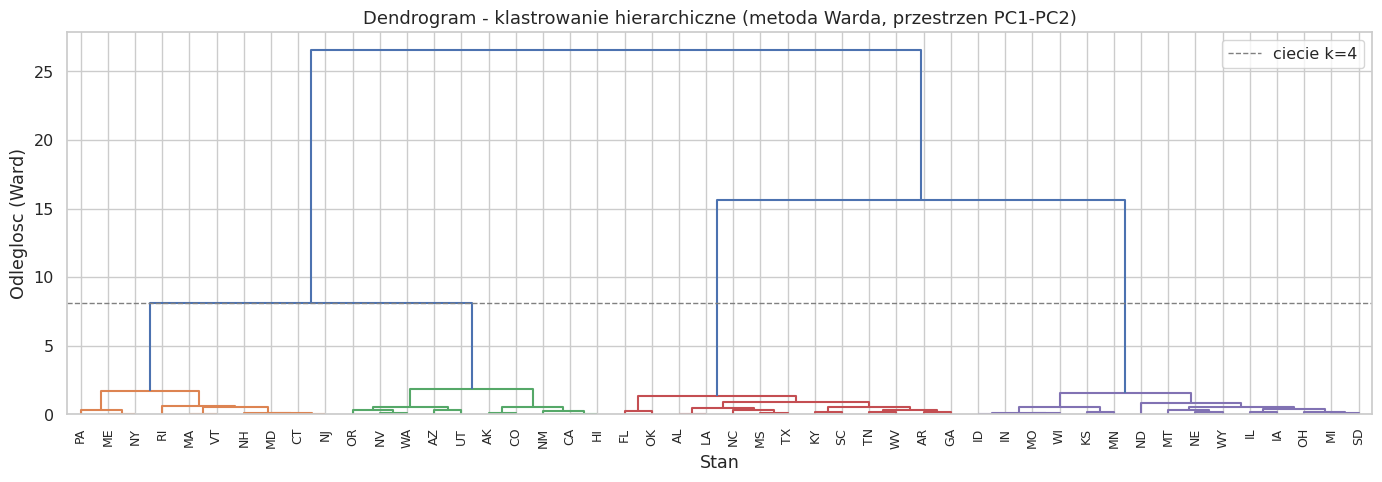

In [75]:
# dendrogram - metoda Warda, przestrzen PC1-PC2
Z = linkage(X_pca2, method="ward")

cut_height = Z[-3, 2]

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    labels=df_state["LocationAbbr"].values,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=cut_height,
    ax=ax,
)
ax.set_title(
    "Dendrogram - klastrowanie hierarchiczne (metoda Warda, przestrzen PC1-PC2)",
    fontsize=13,
)
ax.set_xlabel("Stan")
ax.set_ylabel("Odleglosc (Ward)")
ax.axhline(y=cut_height, linestyle="--", color="gray", linewidth=1, label="ciecie k=4")
ax.legend()
plt.tight_layout()
plt.show()

In [76]:
K_BEST = 4
KLASTER_LABELS = {1: "A", 2: "B", 3: "C", 4: "D"}

labels_hier = fcluster(Z, K_BEST, criterion="maxclust")
df_state["Klaster"] = [KLASTER_LABELS[l] for l in labels_hier]

sil_hier = silhouette_score(X_pca2, labels_hier)
print(f"Silhouette score (k={K_BEST}, Ward, przestrzen PCA): {sil_hier:.3f}")
print()
print("Rozklad klastrow:")
print(df_state["Klaster"].value_counts().sort_index())

Silhouette score (k=4, Ward, przestrzen PCA): 0.827

Rozklad klastrow:
Klaster
A    10
B    10
C    13
D    15
Name: count, dtype: int64


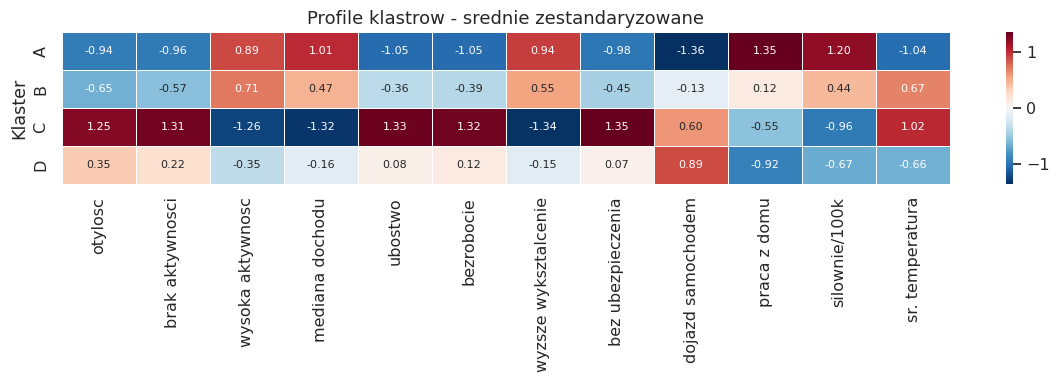

In [77]:
CLUSTER_PALETTE = {"A": "#E41A1C", "B": "#377EB8", "C": "#4DAF4A", "D": "#FF7F00"}

centers = (
    df_state.groupby("Klaster")[CLUSTER_COLS]
    .mean()
    .apply(lambda col: (col - col.mean()) / col.std())
)
centers.columns = [COL_LABELS[c] for c in CLUSTER_COLS]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    centers,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Profile klastrow - srednie zestandaryzowane", fontsize=13)
ax.set_ylabel("Klaster")
plt.tight_layout()
plt.show()

In [78]:
df_pca["Klaster"] = df_state["Klaster"].values

fig1 = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    text="LocationAbbr",
    color="Klaster",
    color_discrete_map=CLUSTER_PALETTE,
    symbol="Region",
    hover_data={"LocationDesc": True, "Obesity": ":.1f", "NoActivity": ":.1f"},
    labels={
        "PC1": f"PC1 ({explained[0]*100:.1f}%)",
        "PC2": f"PC2 ({explained[1]*100:.1f}%)",
    },
    title="Klastry hierarchiczne - PC1 x PC2",
)
fig1.update_traces(textposition="top center", textfont_size=9, marker_size=9)
fig1.update_layout(height=480)
fig1.show()

In [79]:
for k in sorted(df_state["Klaster"].unique()):
    stany = df_state[df_state["Klaster"] == k]["LocationAbbr"].tolist()
    print(f"Klaster {k}: {stany}")

Klaster A: ['CT', 'ME', 'MD', 'MA', 'NH', 'NJ', 'NY', 'PA', 'RI', 'VT']
Klaster B: ['AK', 'AZ', 'CA', 'CO', 'HI', 'NV', 'NM', 'OR', 'UT', 'WA']
Klaster C: ['AL', 'AR', 'FL', 'GA', 'KY', 'LA', 'MS', 'NC', 'OK', 'SC', 'TN', 'TX', 'WV']
Klaster D: ['ID', 'IL', 'IN', 'IA', 'KS', 'MI', 'MN', 'MO', 'MT', 'NE', 'ND', 'OH', 'SD', 'WI', 'WY']


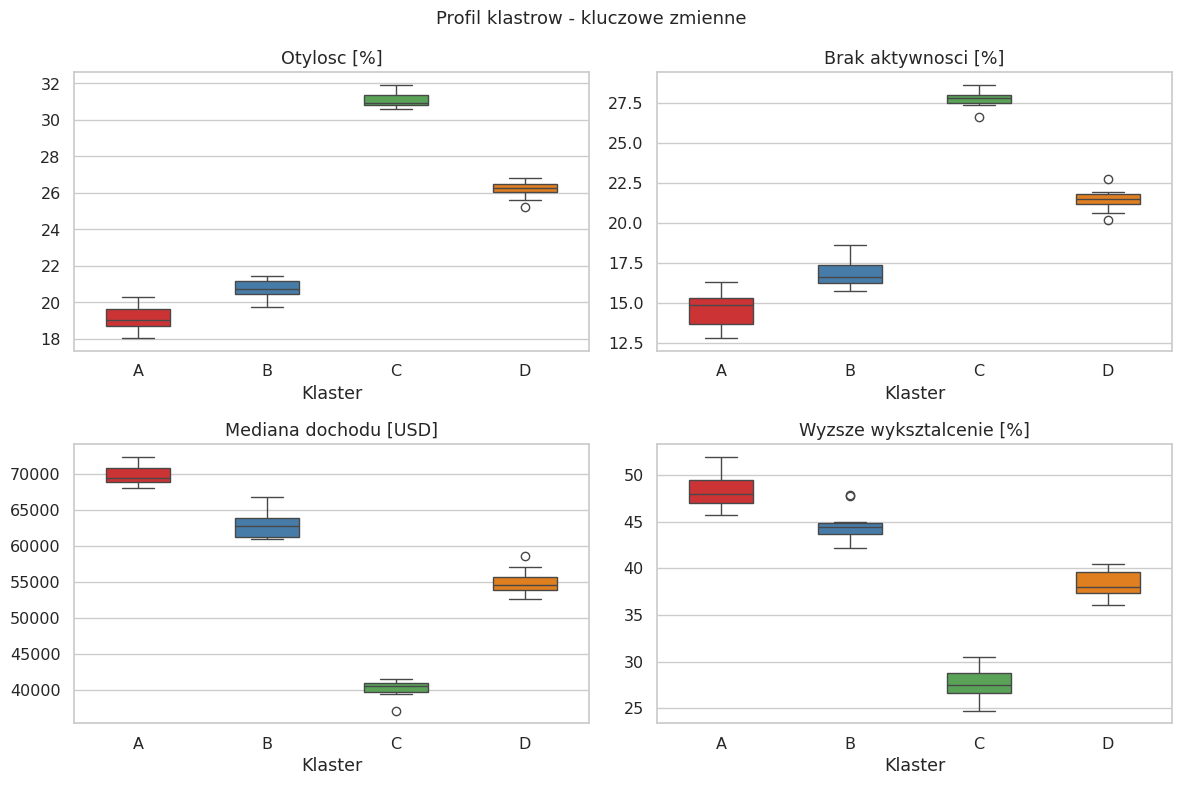

In [80]:
BOX_VARS = [
    ("Obesity", "Otylosc [%]"),
    ("NoActivity", "Brak aktywnosci [%]"),
    ("mediana_dochodu_gosp_dom", "Mediana dochodu [USD]"),
    ("pct_wyksztalcenie_wyzsze", "Wyzsze wyksztalcenie [%]"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, BOX_VARS):
    sns.boxplot(
        data=df_state,
        x="Klaster",
        y=col,
        palette=CLUSTER_PALETTE,
        order=sorted(df_state["Klaster"].unique()),
        width=0.5,
        ax=ax,
    )
    ax.set_title(label)
    ax.set_xlabel("Klaster")
    ax.set_ylabel("")

plt.suptitle("Profil klastrow - kluczowe zmienne", fontsize=13)
plt.tight_layout()
plt.show()

In [81]:
import plotly.express as px

fig = px.choropleth(
    df_state,
    locations="LocationAbbr",
    locationmode="USA-states",
    color="Klaster",
    color_discrete_map=CLUSTER_PALETTE,
    scope="usa",
    hover_name="LocationDesc",
    hover_data={
        "Obesity": ":.1f",
        "NoActivity": ":.1f",
        "mediana_dochodu_gosp_dom": ":,.0f",
    },
    title="Klastry hierarchiczne - mapa USA",
)
fig.update_layout(height=500)


# disable zoom controls and scroll zoom
config = {
    "scrollZoom": False,
    "modeBarButtonsToRemove": [
        "zoom2d",
        "zoomIn2d",
        "zoomOut2d",
        "zoomInGeo",
        "zoomOutGeo",
        "resetScale2d",
        "pan2d",
    ],
}
fig.show(config=config)

# fig.write_image("plots/map_hier.png")

Metoda Warda minimalizuje wariancje wewnatrzklastrow. Dendrogram ujawnia dodatkowa informacje niedostepna w K-Means - mozna odczytac, ktore stany sa do siebie najbardziej podobne (laczą sie na niskiej wysokosci) i ktore sa outlierami w swoim klastrze (dolaczaja pozno, na duzej wysokosci).

Interpretacja klastrow nie pokrywa sie idealnie z wynikami K-Means - klastry są mniej posortowane geograficznie.

## 8. Klastrowanie GMM (Gaussian Mixture Model)

In [84]:
from sklearn.mixture import GaussianMixture

cov_types = ["full", "tied", "diag", "spherical"]
n_components_range = range(2, 9)
gmm_results = []

for cov in cov_types:
    for n in n_components_range:
        gmm = GaussianMixture(n_components=n, covariance_type=cov, random_state=42)
        labels = gmm.fit_predict(X_pca2)
        bic = gmm.bic(X_pca2)
        aic = gmm.aic(X_pca2)
        sil = silhouette_score(X_pca2, labels)
        gmm_results.append({
            "covariance": cov,
            "n_components": n,
            "bic": bic,
            "aic": aic,
            "silhouette": sil,
        })

gmm_results = pd.DataFrame(gmm_results)
best_bic = gmm_results.loc[gmm_results['bic'].idxmin()]
best_sil = gmm_results.loc[gmm_results['silhouette'].idxmax()]
best_gmm_params = best_bic

print('Najlepszy model wg BIC:')
print(best_bic[['covariance', 'n_components', 'bic', 'aic', 'silhouette']])
print('\nNajlepszy model wg silhouette:')
print(best_sil[['covariance', 'n_components', 'bic', 'aic', 'silhouette']])

display(gmm_results.sort_values(['bic', 'silhouette']).head(10))

Najlepszy model wg BIC:
covariance            tied
n_components             4
bic             181.024836
aic             154.828021
silhouette        0.826766
Name: 9, dtype: object

Najlepszy model wg silhouette:
covariance            full
n_components             4
bic              213.95773
aic             170.920107
silhouette        0.826766
Name: 2, dtype: object


,covariance,n_components,bic,aic,silhouette
9,tied,4,181.024836,154.828021,0.826766
10,tied,5,191.291185,159.480768,0.801554
5,full,7,197.828630,121.109388,0.739416
11,tied,6,198.169316,160.745296,0.765307
3,full,5,201.903136,147.638307,0.801554
26,spherical,7,205.591605,155.069177,0.739416
13,tied,8,206.029234,157.378008,0.568151
12,tied,7,208.827047,165.789423,0.739416
4,full,6,211.274651,145.782616,0.765307
19,diag,7,212.590091,148.969256,0.739416


In [87]:
from string import ascii_uppercase

KLASTER_LABELS = {i: ascii_uppercase[i] for i in range(10)}
BASE_CLUSTER_COLORS = [
    '#E41A1C', '#377EB8', '#4DAF4A', '#FF7F00', '#984EA3', '#A65628', '#F781BF', '#999999', '#66C2A5', '#8DA0CB',
]
CLUSTER_PALETTE = {ascii_uppercase[i]: BASE_CLUSTER_COLORS[i] for i in range(len(BASE_CLUSTER_COLORS))}

In [102]:
gmm = GaussianMixture(
    n_components=int(best_gmm_params['n_components']),
    covariance_type=best_gmm_params['covariance'],
    random_state=42,
)
gmm_labels = gmm.fit_predict(X_pca2)

df_state['Klaster_GMM'] = [KLASTER_LABELS[l] for l in gmm_labels]

sil_gmm = silhouette_score(X_pca2, gmm_labels)
print(f"GMM: n_components={int(best_gmm_params['n_components'])}, covariance_type={best_gmm_params['covariance']}")
print(f"Silhouette score: {sil_gmm:.3f}")
print('\nRozklad klastrow GMM:')
print(df_state['Klaster_GMM'].value_counts().sort_index())


GMM: n_components=4, covariance_type=tied
Silhouette score: 0.827

Rozklad klastrow GMM:
Klaster_GMM
A    10
B    13
C    15
D    10
Name: count, dtype: int64


In [89]:
df_pca['Klaster_GMM'] = df_state['Klaster_GMM'].values
CLUSTER_PALETTE = {ascii_uppercase[i]: BASE_CLUSTER_COLORS[i] for i in range(len(BASE_CLUSTER_COLORS))}
fig_gmm = px.scatter(
    df_pca,
    x='PC1',
    y='PC2',
    text='LocationAbbr',
    color='Klaster_GMM',
    color_discrete_map=CLUSTER_PALETTE,
    hover_data=['LocationDesc', 'Obesity', 'NoActivity', 'Region'],
    title=f"Klastrowanie GMM (k={int(best_gmm_params['n_components'])}, cov={best_gmm_params['covariance']}) w przestrzeni PCA",
    height=600,
)
fig_gmm.update_traces(
    textposition='top center', selector=dict(mode='markers+text'), marker=dict(size=12)
)
fig_gmm.add_hline(y=0, line_width=0.5, line_color='lightgray')
fig_gmm.add_vline(x=0, line_width=0.5, line_color='lightgray')
fig_gmm.update_layout(legend_title_text='Klaster_GMM')
fig_gmm.show(config=config)

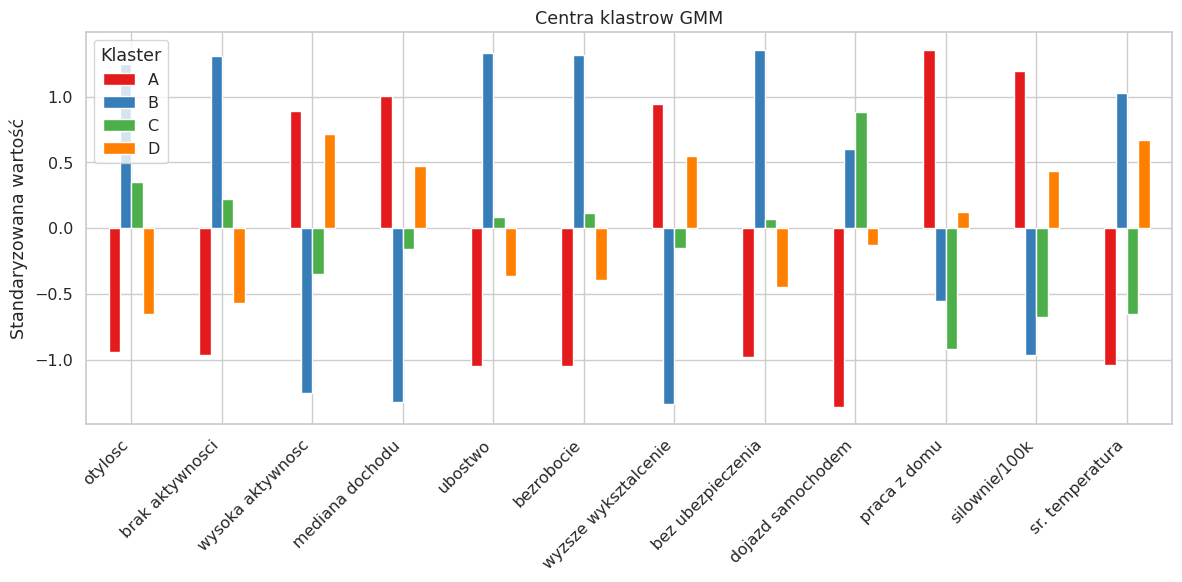

In [90]:
centers_gmm = (
    df_state.groupby("Klaster_GMM")[CLUSTER_COLS]
    .mean()
    .apply(lambda col: (col - col.mean()) / col.std())
)
centers_gmm.columns = [COL_LABELS[c] for c in CLUSTER_COLS]

fig, ax = plt.subplots(figsize=(12, 6))
centers_gmm.T.plot(
    kind="bar", ax=ax, color=[CLUSTER_PALETTE[c] for c in centers_gmm.index]
)
ax.set_title("Centra klastrow GMM")
ax.set_ylabel("Standaryzowana wartość")
ax.legend(title="Klaster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [91]:
fig = px.choropleth(
    df_state,
    locations="LocationAbbr",
    locationmode="USA-states",
    color="Klaster_GMM",
    color_discrete_map=CLUSTER_PALETTE,
    scope="usa",
    hover_name="LocationDesc",
    hover_data={
        "Obesity": ":.1f",
        "NoActivity": ":.1f",
        "mediana_dochodu_gosp_dom": ":,.0f",
    },
    title="Klastry GMM - mapa USA",
)
fig.update_layout(height=500)
fig.show(config=config)

# fig.write_image("plots/map_gmm.png")

## 9. K-Means

In [92]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

k_range = range(2, 11)
kmeans_results = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca2)
    sil = silhouette_score(X_pca2, labels)
    dbs = davies_bouldin_score(X_pca2, labels)
    kmeans_results.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': dbs,
        'inertia': kmeans.inertia_,
    })

kmeans_results = pd.DataFrame(kmeans_results)
best_k = int(kmeans_results.loc[kmeans_results['silhouette'].idxmax(), 'k'])
print(f'Najlepsze k dla KMeans (silhouette): {best_k}')
display(kmeans_results.sort_values('silhouette', ascending=False).head(10))

Najlepsze k dla KMeans (silhouette): 4


,k,silhouette,davies_bouldin,inertia
2,4,0.826766,0.265926,7.854570
3,5,0.785895,0.325696,6.208076
4,6,0.765307,0.352444,4.697141
1,3,0.756228,0.339350,41.034538
5,7,0.669335,0.452489,3.390344
0,2,0.611009,0.629163,163.403303
6,8,0.568151,0.510890,2.458080
7,9,0.535635,0.598910,2.057230
8,10,0.522176,0.560397,1.763608


In [93]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_pca2)

df_state['Klaster_KMeans'] = [KLASTER_LABELS[l] for l in kmeans_labels]

sil_km = silhouette_score(X_pca2, kmeans_labels)
print(f'KMeans k = {best_k}')
print(f'Silhouette score: {sil_km:.3f}')
print('\nRozklad klastrow KMeans:')
print(df_state['Klaster_KMeans'].value_counts().sort_index())


KMeans k = 4
Silhouette score: 0.827

Rozklad klastrow KMeans:
Klaster_KMeans
A    10
B    13
C    15
D    10
Name: count, dtype: int64


In [94]:
df_pca['Klaster_KMeans'] = df_state['Klaster_KMeans'].values
CLUSTER_PALETTE = {ascii_uppercase[i]: BASE_CLUSTER_COLORS[i] for i in range(len(BASE_CLUSTER_COLORS))}
fig_km = px.scatter(
    df_pca,
    x='PC1',
    y='PC2',
    text='LocationAbbr',
    color='Klaster_KMeans',
    color_discrete_map=CLUSTER_PALETTE,
    hover_data=['LocationDesc', 'Obesity', 'NoActivity', 'Region'],
    title=f'Klastrowanie KMeans (k={best_k}) w przestrzeni PCA',
    height=600,
)
fig_km.update_traces(textposition='top center', selector=dict(mode='markers+text'))
fig_km.add_hline(y=0, line_width=0.5, line_color='lightgray')
fig_km.add_vline(x=0, line_width=0.5, line_color='lightgray')
fig_km.update_layout(legend_title_text='Klaster_KMeans')
fig_km.show(config=config)


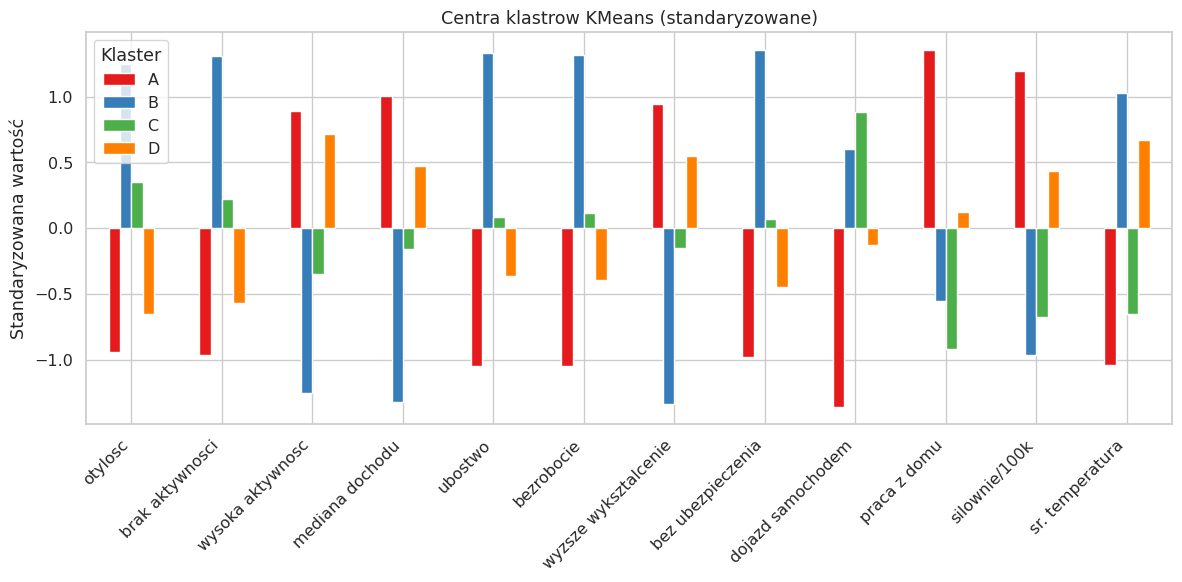

In [95]:
centers_km = (
    df_state.groupby("Klaster_KMeans")[CLUSTER_COLS]
    .mean()
    .apply(lambda col: (col - col.mean()) / col.std())
)

centers_km.columns = [COL_LABELS[c] for c in CLUSTER_COLS]

fig, ax = plt.subplots(figsize=(12, 6))
centers_km.T.plot(
    kind="bar", ax=ax, color=[CLUSTER_PALETTE[c] for c in centers_km.index]
)

ax.set_title("Centra klastrow KMeans (standaryzowane)")
ax.set_ylabel("Standaryzowana wartość")
ax.legend(title="Klaster")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [96]:
fig = px.choropleth(
    df_state,
    locations="LocationAbbr",
    locationmode="USA-states",
    color="Klaster_KMeans",
    color_discrete_map=CLUSTER_PALETTE,
    scope="usa",
    hover_name="LocationDesc",
    hover_data={
        "Obesity": ":.1f",
        "NoActivity": ":.1f",
        "mediana_dochodu_gosp_dom": ":,.0f",
    },
    title="Klastry K-Means - mapa USA",
)
fig.update_layout(height=500)
fig.show(config=config)

# fig.write_image("plots/map_kmeans.png")

## 10. Porównanie

In [97]:
print("\nAktualne wyniki silhouette score:")
print(f"KMeans: {sil_km:.3f}")
print(f"GMM: {sil_gmm:.3f}")
print(f"Hierarchical: {sil_hier:.3f}")


Aktualne wyniki silhouette score:
KMeans: 0.827
GMM: 0.827
Hierarchical: 0.827


In [98]:
from sklearn.metrics import davies_bouldin_score

dbs_kmeans = davies_bouldin_score(X_pca2, kmeans_labels)
dbs_gmm = davies_bouldin_score(X_pca2, gmm_labels)
dbs_hier = davies_bouldin_score(X_pca2, labels_hier)

print("\nAktualne wyniki Davies-Bouldin score:")
print(f"KMeans: {dbs_kmeans:.3f}")
print(f"GMM: {dbs_gmm:.3f}")
print(f"Hierarchical: {dbs_hier:.3f}")


Aktualne wyniki Davies-Bouldin score:
KMeans: 0.266
GMM: 0.266
Hierarchical: 0.266


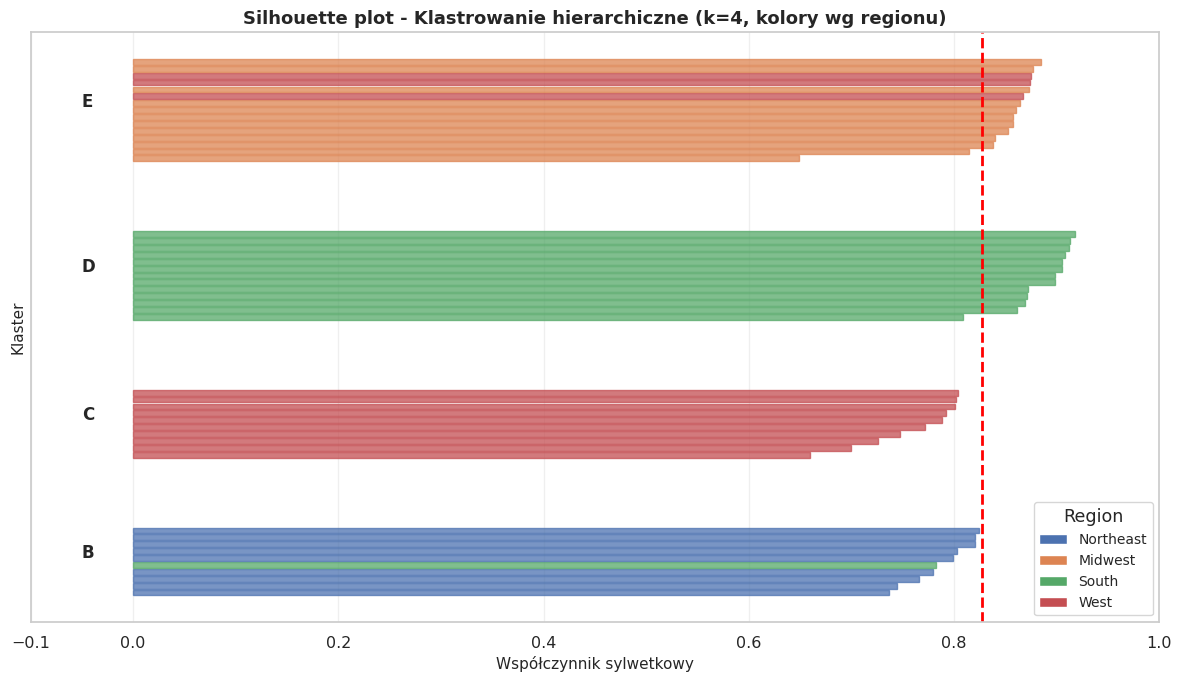

In [99]:
from sklearn.metrics import silhouette_samples
from matplotlib.patches import Patch

sample_silhouette_values = silhouette_samples(X_pca2, labels_hier)

fig, ax = plt.subplots(figsize=(12, 7))

clust_hier = sorted(np.unique(labels_hier))
y_lower = 10

for c in clust_hier:
    # Get mask for states in this cluster
    cluster_mask = labels_hier == c

    # Get indices and silhouette values for this cluster
    cluster_sil_values = sample_silhouette_values[cluster_mask]
    cluster_indices = np.where(cluster_mask)[0]

    # Sort by silhouette value
    sorted_positions = np.argsort(cluster_sil_values)

    size_cluster_i = len(cluster_indices)
    y_upper = y_lower + size_cluster_i

    # Draw bar for each state
    for i in range(size_cluster_i):
        # Get the state index in original data
        state_idx = cluster_indices[sorted_positions[i]]

        # Get region and silhouette value
        region = df_state.iloc[state_idx]["Region"]
        color = PALETTE[region]
        sil_val = cluster_sil_values[sorted_positions[i]]

        # Draw horizontal bar
        y_pos = y_lower + i
        ax.barh(
            y_pos,
            sil_val,
            height=0.85,
            left=0,
            facecolor=color,
            edgecolor=color,
            alpha=0.75,
        )

    # Label cluster
    cluster_label = KLASTER_LABELS[c]
    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        cluster_label,
        fontsize=12,
        fontweight="bold",
    )

    y_lower = y_upper + 10

ax.set_title(
    "Silhouette plot - Klastrowanie hierarchiczne (k=4, kolory wg regionu)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Współczynnik sylwetkowy", fontsize=11)
ax.set_ylabel("Klaster", fontsize=11)

ax.axvline(
    x=sil_hier,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Średni wynik: {sil_hier:.3f}",
)

ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Add legend for regions
legend_elements = [
    Patch(facecolor=PALETTE[region], label=region)
    for region in ["Northeast", "Midwest", "South", "West"]
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right", title="Region")

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

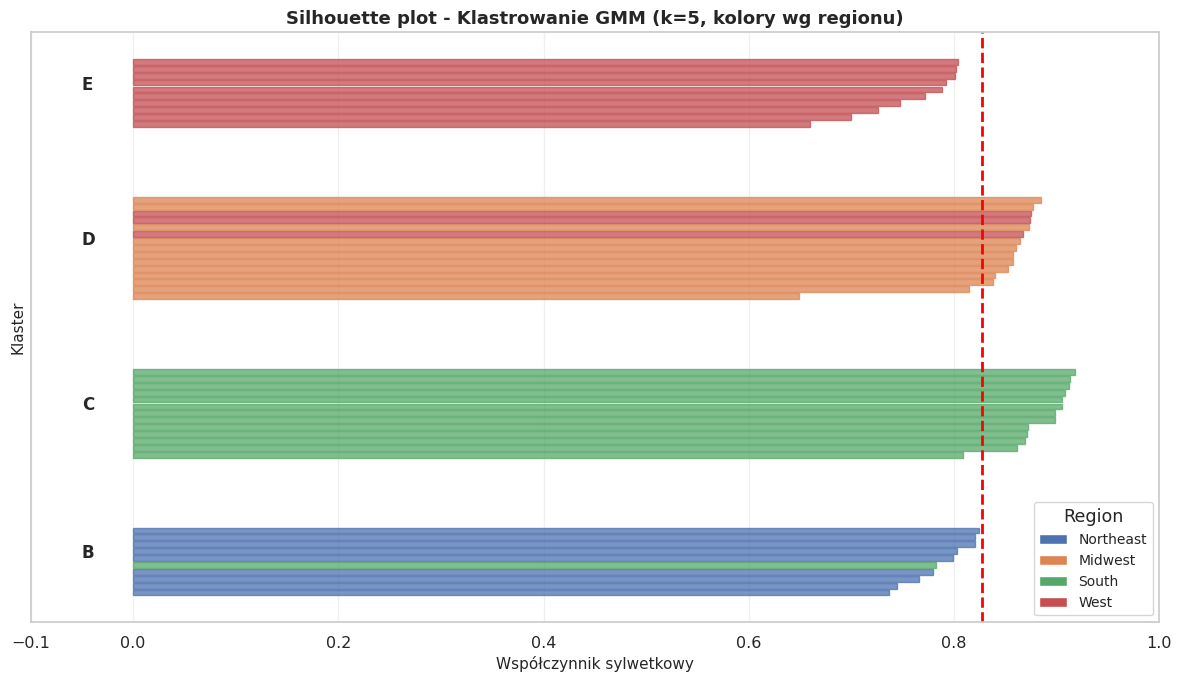

In [100]:
from sklearn.metrics import silhouette_samples
from matplotlib.patches import Patch

sample_silhouette_values = silhouette_samples(X_pca2, gmm_labels)

fig, ax = plt.subplots(figsize=(12, 7))

clust_gmm = sorted(np.unique(gmm_labels))
y_lower = 10

for c in clust_gmm:
    # Get mask for states in this cluster
    cluster_mask = gmm_labels == c

    # Get indices and silhouette values for this cluster
    cluster_sil_values = sample_silhouette_values[cluster_mask]
    cluster_indices = np.where(cluster_mask)[0]

    # Sort by silhouette value
    sorted_positions = np.argsort(cluster_sil_values)

    size_cluster_i = len(cluster_indices)
    y_upper = y_lower + size_cluster_i

    # Draw bar for each state
    for i in range(size_cluster_i):
        # Get the state index in original data
        state_idx = cluster_indices[sorted_positions[i]]

        # Get region and silhouette value
        region = df_state.iloc[state_idx]["Region"]
        color = PALETTE[region]
        sil_val = cluster_sil_values[sorted_positions[i]]

        # Draw horizontal bar
        y_pos = y_lower + i
        ax.barh(
            y_pos,
            sil_val,
            height=0.85,
            left=0,
            facecolor=color,
            edgecolor=color,
            alpha=0.75,
        )

    # Label cluster
    cluster_label = KLASTER_LABELS[c + 1]
    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        cluster_label,
        fontsize=12,
        fontweight="bold",
    )

    y_lower = y_upper + 10

ax.set_title(
    "Silhouette plot - Klastrowanie GMM (k=5, kolory wg regionu)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Współczynnik sylwetkowy", fontsize=11)
ax.set_ylabel("Klaster", fontsize=11)

ax.axvline(
    x=sil_gmm,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Średni wynik: {sil_gmm:.3f}",
)

ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Add legend for regions
legend_elements = [
    Patch(facecolor=PALETTE[region], label=region)
    for region in ["Northeast", "Midwest", "South", "West"]
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right", title="Region")

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

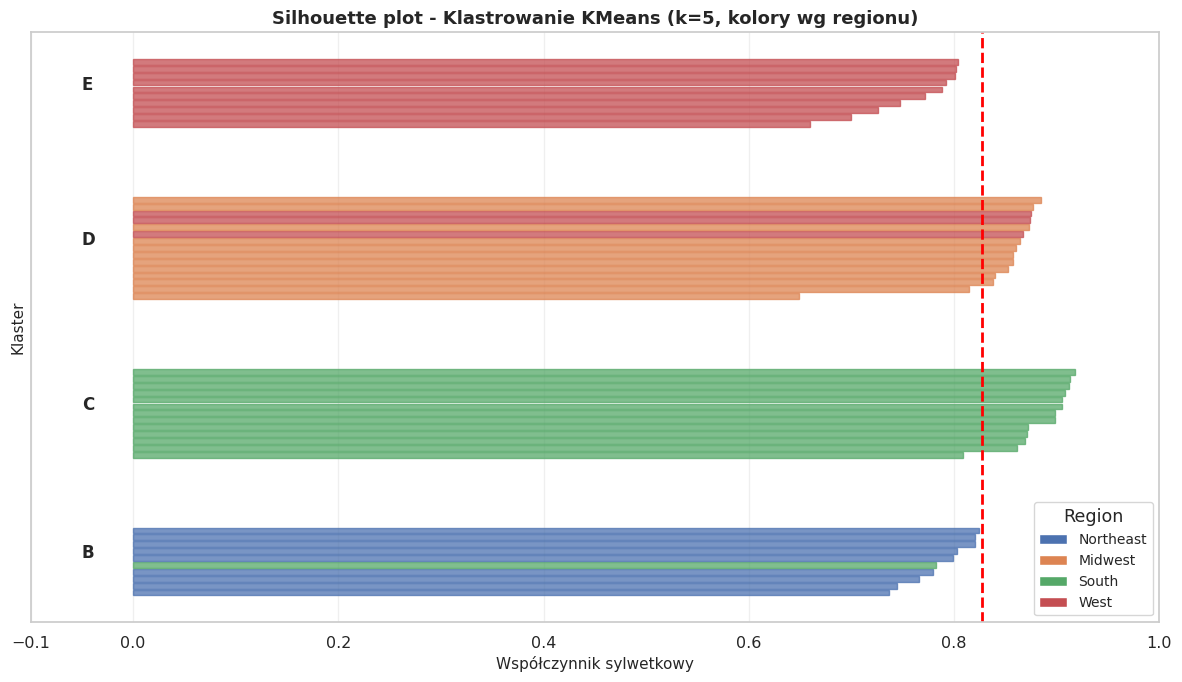

In [101]:
from sklearn.metrics import silhouette_samples
from matplotlib.patches import Patch

sample_silhouette_values = silhouette_samples(X_pca2, kmeans_labels)

fig, ax = plt.subplots(figsize=(12, 7))

clust_km = sorted(np.unique(kmeans_labels))
y_lower = 10

for c in clust_km:
    # Get mask for states in this cluster
    cluster_mask = kmeans_labels == c

    # Get indices and silhouette values for this cluster
    cluster_sil_values = sample_silhouette_values[cluster_mask]
    cluster_indices = np.where(cluster_mask)[0]

    # Sort by silhouette value
    sorted_positions = np.argsort(cluster_sil_values)

    size_cluster_i = len(cluster_indices)
    y_upper = y_lower + size_cluster_i

    # Draw bar for each state
    for i in range(size_cluster_i):
        # Get the state index in original data
        state_idx = cluster_indices[sorted_positions[i]]

        # Get region and silhouette value
        region = df_state.iloc[state_idx]["Region"]
        color = PALETTE[region]
        sil_val = cluster_sil_values[sorted_positions[i]]

        # Draw horizontal bar
        y_pos = y_lower + i
        ax.barh(
            y_pos,
            sil_val,
            height=0.85,
            left=0,
            facecolor=color,
            edgecolor=color,
            alpha=0.75,
        )

    # Label cluster
    cluster_label = KLASTER_LABELS[c + 1]
    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        cluster_label,
        fontsize=12,
        fontweight="bold",
    )

    y_lower = y_upper + 10

ax.set_title(
    "Silhouette plot - Klastrowanie KMeans (k=5, kolory wg regionu)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Współczynnik sylwetkowy", fontsize=11)
ax.set_ylabel("Klaster", fontsize=11)

ax.axvline(
    x=sil_km,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Średni wynik: {sil_km:.3f}",
)

ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Add legend for regions
legend_elements = [
    Patch(facecolor=PALETTE[region], label=region)
    for region in ["Northeast", "Midwest", "South", "West"]
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right", title="Region")

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()